# Modelling

**Kelompok G02:** 
- Inggried Amelia Deswanty - 18223035
- Muhammad Aqmar Fayyaz Zakaria - 18223043 
- Amudi Purba - 18223049
- Nadia Apsarini Baizal - 18223065
- Velicia Christina Gabriel - 18223085

In [1]:
import textwrap
import os, re, json, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix)
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack

### Train/Test Split

In [18]:
RANDOM_STATE = 42
DATA_DIR = Path(".")
clf_df = pd.read_csv(DATA_DIR / "prepared_classification.csv")
print(f"Data loaded: {clf_df.shape[0]} rows × {clf_df.shape[1]} cols")

X_full   = clf_df["resume_clean"].astype(str)
y_family = clf_df["Family"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_family, test_size=0.2,
    stratify=y_family, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train)}  Test: {len(X_test)}")

Data loaded: 2468 rows × 4 cols
Train: 1974  Test: 494


## 1. Modelling

In [3]:
print(f"Classification data ready: {clf_df.shape[0]} rows × {clf_df.shape[1]} cols")
print(f"Train/test split complete: {len(X_train)} train, {len(X_test)} test")


Classification data ready: 2468 rows × 4 cols
Train/test split complete: 1974 train, 494 test


### Vectorization

In [4]:
word_vec = TfidfVectorizer(
    max_features=30_000, ngram_range=(1, 2),
    min_df=2, max_df=0.9,
    sublinear_tf=True, stop_words="english",
)
char_vec = TfidfVectorizer(
    max_features=15_000, ngram_range=(3, 5),
    min_df=2, sublinear_tf=True, analyzer="char_wb",
)

Xw_tr = word_vec.fit_transform(X_train);  Xw_te = word_vec.transform(X_test)
Xc_tr = char_vec.fit_transform(X_train);  Xc_te = char_vec.transform(X_test)

X_tr = hstack([Xw_tr, Xc_tr]).tocsr()
X_te = hstack([Xw_te, Xc_te]).tocsr()

print(f"Feature dimensionality: {X_tr.shape[1]:,}")

Feature dimensionality: 45,000


In [5]:
base_clf = LogisticRegression(max_iter=5000, C=1.0, solver="saga",
                               random_state=RANDOM_STATE)
base_clf.fit(X_tr, y_train)
base_pred = base_clf.predict(X_te)

print("=== Baseline (default C=1) — 4-family ===")
print(f"Accuracy   : {accuracy_score(y_test, base_pred):.4f}")
print(f"Precision  : {precision_score(y_test, base_pred, average='macro', zero_division=0):.4f}")
print(f"Recall     : {recall_score(y_test, base_pred, average='macro', zero_division=0):.4f}")
print(f"F1 Macro   : {f1_score(y_test, base_pred, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test, base_pred, average='weighted'):.4f}")

=== Baseline (default C=1) — 4-family ===
Accuracy   : 0.7915
Precision  : 0.8109
Recall     : 0.7118
F1 Macro   : 0.7325
F1 Weighted: 0.7795


In [6]:
cv_base = cross_val_score(
    LogisticRegression(max_iter=5000, C=1.0, solver="saga",
                        random_state=RANDOM_STATE),
    X_tr, y_train, cv=5, scoring="accuracy", n_jobs=-1
)
print(f"5-fold CV accuracy (baseline, 4-family): {cv_base.mean():.4f} ± {cv_base.std():.4f}")

5-fold CV accuracy (baseline, 4-family): 0.7578 ± 0.0200


## 2. Hyperparameter Tuning 

In [7]:
param_grid = {
    "C":       [1, 5, 10, 20, 50, 100],
    "penalty": ["l1", "l2"],
    "solver":  ["saga"],
}

gs = GridSearchCV(
    LogisticRegression(max_iter=5000, class_weight="balanced",
                        random_state=RANDOM_STATE),
    param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
    refit=True,
)
gs.fit(X_tr, y_train)

print(f"\nBest params : {gs.best_params_}")
print(f"Best CV F1  : {gs.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best params : {'C': 50, 'penalty': 'l1', 'solver': 'saga'}
Best CV F1  : 0.8237


In [8]:
cv_results = pd.DataFrame(gs.cv_results_)
top = (cv_results
       .sort_values("mean_test_score", ascending=False)
       [["param_C", "param_penalty", "mean_test_score", "std_test_score"]]
       .head(10)
       .rename(columns={
           "param_C": "C",
           "param_penalty": "penalty",
           "mean_test_score": "CV F1 macro (mean)",
           "std_test_score": "CV F1 macro (std)",
       })
       .reset_index(drop=True))
top.index += 1
print(top.to_string())

      C penalty  CV F1 macro (mean)  CV F1 macro (std)
1    50      l1            0.823747           0.012319
2    10      l1            0.823612           0.008577
3    20      l1            0.821493           0.006132
4   100      l1            0.820953           0.005507
5     5      l1            0.815775           0.018523
6     1      l1            0.773956           0.026655
7    20      l2            0.744328           0.006196
8    50      l2            0.744302           0.006303
9     5      l2            0.743623           0.004980
10   10      l2            0.741845           0.004617


## 3. Evaluation

In [9]:
best = gs.best_estimator_
best_pred = best.predict(X_te)

acc  = accuracy_score(y_test, best_pred)
prec = precision_score(y_test, best_pred, average="macro", zero_division=0)
rec  = recall_score(y_test, best_pred,    average="macro", zero_division=0)
f1_m = f1_score(y_test, best_pred,        average="macro")
f1_w = f1_score(y_test, best_pred,        average="weighted")

print("=== Final Model ===")
print(f"Accuracy        : {acc:.4f}")
print(f"Precision macro : {prec:.4f}")
print(f"Recall macro    : {rec:.4f}")
print(f"F1 Macro        : {f1_m:.4f}")
print(f"F1 Weighted     : {f1_w:.4f}")
print()
print(classification_report(y_test, best_pred, digits=3))

=== Final Model ===
Accuracy        : 0.8502
Precision macro : 0.8397
Recall macro    : 0.8193
F1 Macro        : 0.8265
F1 Weighted     : 0.8487

              precision    recall  f1-score   support

    BUSINESS      0.877     0.885     0.881       226
    CREATIVE      0.833     0.656     0.734        61
    SERVICES      0.802     0.853     0.827        95
        TECH      0.846     0.884     0.865       112

    accuracy                          0.850       494
   macro avg      0.840     0.819     0.827       494
weighted avg      0.850     0.850     0.849       494



In [10]:
cv_final = cross_val_score(
    gs.best_estimator_,
    X_tr, y_train, cv=5, scoring="accuracy", n_jobs=-1
)
print(f"5-fold CV accuracy: {cv_final.mean():.4f} ± {cv_final.std():.4f}")
print(f"Test accuracy: {acc:.4f}")

5-fold CV accuracy: 0.8475 ± 0.0123
Test accuracy: 0.8502


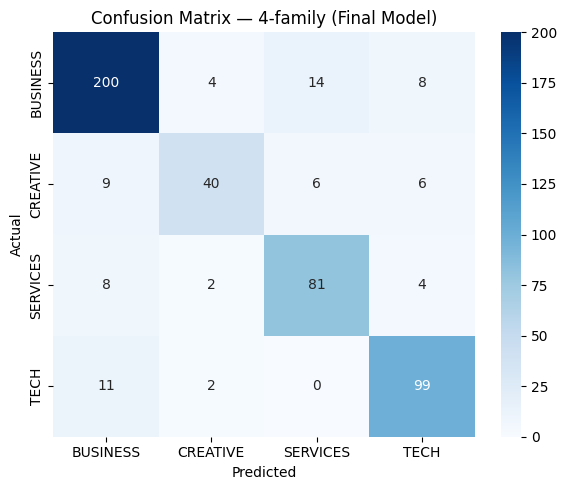

In [11]:
# Confusion matrix
fam_labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, best_pred, labels=fam_labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=fam_labels, yticklabels=fam_labels, ax=ax)
ax.set_title("Confusion Matrix — 4-family (Final Model)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

In [12]:
summary = pd.DataFrame({
    "Model": [
        "Baseline (C=1, saga)",
        "Tuned (best params)",
    ],
    "Accuracy": [
        accuracy_score(y_test, base_pred),
        acc,
    ],
    "F1 Macro": [
        f1_score(y_test, base_pred, average="macro"),
        f1_m,
    ],
})
print(summary.round(4).to_string(index=False))

               Model  Accuracy  F1 Macro
Baseline (C=1, saga)    0.7915    0.7325
 Tuned (best params)    0.8502    0.8265


### Simpan Artefak

In [13]:
out = Path(".")
joblib.dump(best,      out / "lr_classifier_family.pkl")
joblib.dump(word_vec,  out / "tfidf_word.pkl")
joblib.dump(char_vec,  out / "tfidf_char.pkl")

print("Saved artefacts:")
for f in ["lr_classifier_family.pkl", "tfidf_word.pkl", "tfidf_char.pkl"]:
    p = out / f
    print(f"  {f:<32}  {p.stat().st_size/1024:>7.1f} KB")

Saved artefacts:
  lr_classifier_family.pkl           1407.3 KB
  tfidf_word.pkl                     1269.8 KB
  tfidf_char.pkl                      502.7 KB


### Inference Function 

In [14]:
def load_classifier(model_dir: str = "."):
    d = Path(model_dir)
    model    = joblib.load(d / "lr_classifier_family.pkl")
    word_vec = joblib.load(d / "tfidf_word.pkl")
    char_vec = joblib.load(d / "tfidf_char.pkl")
    return model, word_vec, char_vec


def predict_family(resume_text: str,
                   model, word_vec, char_vec) -> dict:
    DATE_RE = re.compile(
        r"\b(jan|feb|mar|apr|may|jun|jul|aug|sep|sept|oct|nov|dec)"
        r"(uary|ruary|ch|il|e|y|ust|tember|ober|ember)?\b"
    )
    def _clean(s: str) -> str:
        s = s.lower()
        s = re.sub(r"<[^>]+>",           " ", s)
        s = re.sub(r"\S+@\S+",           " ", s)
        s = re.sub(r"http\S+|www\.\S+",  " ", s)
        s = re.sub(r"\b\d{7,}\b",        " ", s)
        s = DATE_RE.sub(                 " ", s)
        s = re.sub(r"\d+",               " ", s)
        s = re.sub(r"[^\w\s+#\.]",       " ", s)
        return re.sub(r"\s+", " ", s).strip()

    cleaned  = _clean(resume_text)
    xw       = word_vec.transform([cleaned])
    xc       = char_vec.transform([cleaned])
    feat     = hstack([xw, xc]).tocsr()

    pred     = model.predict(feat)[0]
    proba    = dict(zip(model.classes_,
                        model.predict_proba(feat)[0].round(4)))

    return {
        "predicted_family" : pred,
        "confidence"       : round(float(proba[pred]), 4),
        "probabilities"    : dict(sorted(proba.items(),
                                         key=lambda x: -x[1])),
    }

In [15]:
 model_prod, wv_prod, cv_prod = load_classifier(".")

test_samples = (
    clf_df.groupby("Family", group_keys=False)
          .apply(lambda x: x.sample(1, random_state=RANDOM_STATE))
          .reset_index(drop=True)
)

print("=== Sanity Check — Inference Function ===\n")
all_correct = True
for _, row in test_samples.iterrows():
    result = predict_family(row["resume_clean"], model_prod, wv_prod, cv_prod)
    status = "✅" if result["predicted_family"] == row["Family"] else "❌"
    if result["predicted_family"] != row["Family"]:
        all_correct = False
    print(f"{status}  Actual: {row['Family']:<10}  "
          f"Predicted: {result['predicted_family']:<10}  "
          f"Confidence: {result['confidence']:.4f}")
    print(f"     Probabilities: {result['probabilities']}\n")

print("Inference function siap dipakai oleh API." if all_correct
      else "Ada misprediksi — periksa sample atau model.")

=== Sanity Check — Inference Function ===

✅  Actual: BUSINESS    Predicted: BUSINESS    Confidence: 0.9955
     Probabilities: {'BUSINESS': np.float64(0.9955), 'CREATIVE': np.float64(0.0031), 'SERVICES': np.float64(0.0007), 'TECH': np.float64(0.0007)}

✅  Actual: CREATIVE    Predicted: CREATIVE    Confidence: 0.9872
     Probabilities: {'CREATIVE': np.float64(0.9872), 'BUSINESS': np.float64(0.0091), 'TECH': np.float64(0.0032), 'SERVICES': np.float64(0.0005)}

✅  Actual: SERVICES    Predicted: SERVICES    Confidence: 0.9883
     Probabilities: {'SERVICES': np.float64(0.9883), 'CREATIVE': np.float64(0.0085), 'BUSINESS': np.float64(0.0028), 'TECH': np.float64(0.0004)}

✅  Actual: TECH        Predicted: TECH        Confidence: 0.9902
     Probabilities: {'TECH': np.float64(0.9902), 'CREATIVE': np.float64(0.0096), 'BUSINESS': np.float64(0.0001), 'SERVICES': np.float64(0.0001)}

Inference function siap dipakai oleh API.


C:\Users\Velicia\AppData\Local\Temp\ipykernel_39996\188260975.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1, random_state=RANDOM_STATE))


## 18. Integration Wrapper

In [16]:
CONFIDENCE_THRESHOLD = 0.75

def extract_text_from_json(cv_json: dict) -> str:
    for field in ["raw_text", "full_text", "text", "resume_text", "content"]:
        if cv_json.get(field):
            return str(cv_json[field])

    parts = []

    if cv_json.get("name"):
        parts.append(f"Name: {cv_json['name']}.")

    if cv_json.get("current_job_title") or cv_json.get("current_role"):
        title = cv_json.get("current_job_title") or cv_json.get("current_role")
        parts.append(f"Current role: {title}.")

    if cv_json.get("previous_job_titles") or cv_json.get("previous_roles"):
        prev = cv_json.get("previous_job_titles") or cv_json.get("previous_roles")
        if isinstance(prev, list):
            prev = ", ".join(prev)
        parts.append(f"Previous roles: {prev}.")

    if cv_json.get("skills"):
        skills = cv_json["skills"]
        if isinstance(skills, list):
            skills = ", ".join(skills)
        parts.append(f"Skills: {skills}.")

    if cv_json.get("education"):
        edu = cv_json["education"]
        if isinstance(edu, dict):
            level = edu.get("level", "")
            field = edu.get("field", "")
            edu = f"{level} in {field}" if field else level
        parts.append(f"Education: {edu}.")

    if cv_json.get("education_level"):
        parts.append(f"Education: {cv_json['education_level']}.")

    if cv_json.get("experience_years") is not None:
        parts.append(f"Experience: {cv_json['experience_years']} years.")

    if cv_json.get("certifications"):
        certs = cv_json["certifications"]
        if isinstance(certs, list):
            certs = ", ".join(certs)
        parts.append(f"Certifications: {certs}.")

    if cv_json.get("summary") or cv_json.get("objective"):
        summary = cv_json.get("summary") or cv_json.get("objective")
        parts.append(f"Summary: {summary}.")

    if not parts:
        raise ValueError(
            "JSON tidak mengandung field yang dikenali. "
            "Pastikan format JSON output Nadia sesuai dokumentasi."
        )

    return " ".join(parts)

def classify_from_json(cv_json: dict, model, word_vec, char_vec) -> dict:
    resume_text = extract_text_from_json(cv_json)
    result = predict_family(resume_text, model, word_vec, char_vec)
    result["extracted_text_preview"] = resume_text[:200] + "..." \
                                       if len(resume_text) > 200 else resume_text
    result["needs_human_review"] = result["confidence"] < CONFIDENCE_THRESHOLD

    return result

In [17]:
mock_json_A = {
    "raw_text": clf_df["resume_clean"].iloc[0],
    "name": "John Doe",
    "skills": ["python", "sql", "aws"],
}

mock_json_B = {
    "name": "Jane Smith",
    "current_job_title": "Data Scientist",
    "previous_job_titles": ["Data Analyst", "Research Assistant"],
    "skills": ["python", "tensorflow", "sql", "aws", "kubernetes"],
    "education_level": "Master's in Computer Science",
    "experience_years": 4,
    "certifications": "AWS Certified Machine Learning Specialty",
}

mock_json_C = {
    "name": "Budi Santoso",
    "current_job_title": "Financial Analyst",
    "skills": ["accounting", "finance", "excel", "audit", "risk"],
    "education_level": "Bachelor's in Accounting",
    "experience_years": 3,
}

model_prod, wv_prod, cv_prod = load_classifier(".")

print("=== Integration Wrapper Sanity Check ===\n")
for label, mock in [("A (raw_text)", mock_json_A),
                     ("B (structured, TECH)", mock_json_B),
                     ("C (structured, BUSINESS)", mock_json_C)]:
    result = classify_from_json(mock, model_prod, wv_prod, cv_prod)
    preview = result['extracted_text_preview']
    wrapped = textwrap.fill(preview, width=70, 
                            initial_indent="  ", 
                            subsequent_indent="  ")
    print(f"Mock {label}")
    print(f"  Predicted : {result['predicted_family']}")
    print(f"  Confidence: {result['confidence']}")
    print(f"  Needs HR review: {result['needs_human_review']}")
    print(f"  Preview   :\n{wrapped}\n")


=== Integration Wrapper Sanity Check ===

Mock A (raw_text)
  Predicted : BUSINESS
  Confidence: 0.9842
  Needs HR review: False
  Preview   :
  hr administrator marketing associate hr administrator summary
  dedicated customer service manager with + years of experience in
  hospitality and customer service management. respected builder and
  leader...

Mock B (structured, TECH)
  Predicted : BUSINESS
  Confidence: 0.6698
  Needs HR review: True
  Preview   :
  Name: Jane Smith. Current role: Data Scientist. Previous roles: Data
  Analyst, Research Assistant. Skills: python, tensorflow, sql, aws,
  kubernetes. Education: Master's in Computer Science. Experience:...

Mock C (structured, BUSINESS)
  Predicted : BUSINESS
  Confidence: 1.0
  Needs HR review: False
  Preview   :
  Name: Budi Santoso. Current role: Financial Analyst. Skills:
  accounting, finance, excel, audit, risk. Education: Bachelor's in
  Accounting. Experience: 3 years.

